FDR file columns:
['pairing_num', 'FDR_distance']

Parameter file columns:
['pairing_num', 'rand1', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19', 'k20']

Number of matched settings: 400

Selected 28 parameters:
['T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19', 'k20']

Number of matched settings: 400

Final selected columns:
['pairing_num', 'FDR_distance', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19', 'k20']

First five selected rows:
   pairing_num  FDR_distance      T3      T4      T5      T6      T7      T8  \
0          176     12.549178  250.89  246.36  250.14  249.19  198.78  203.78   
1          2

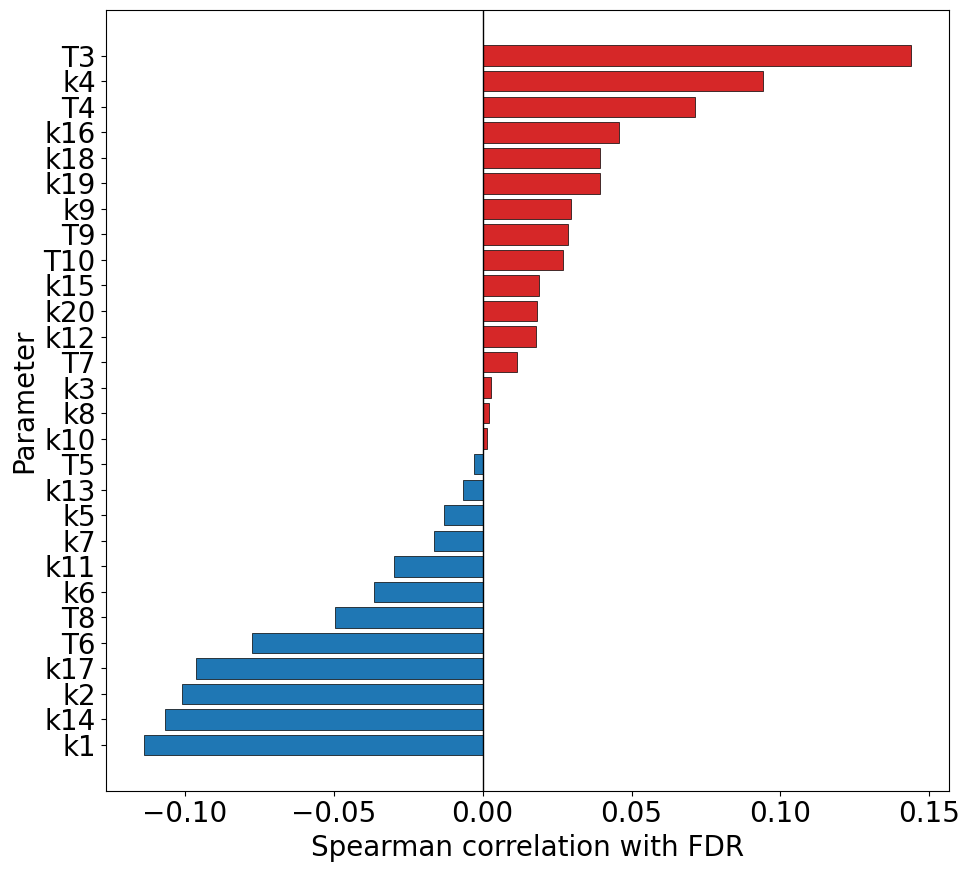

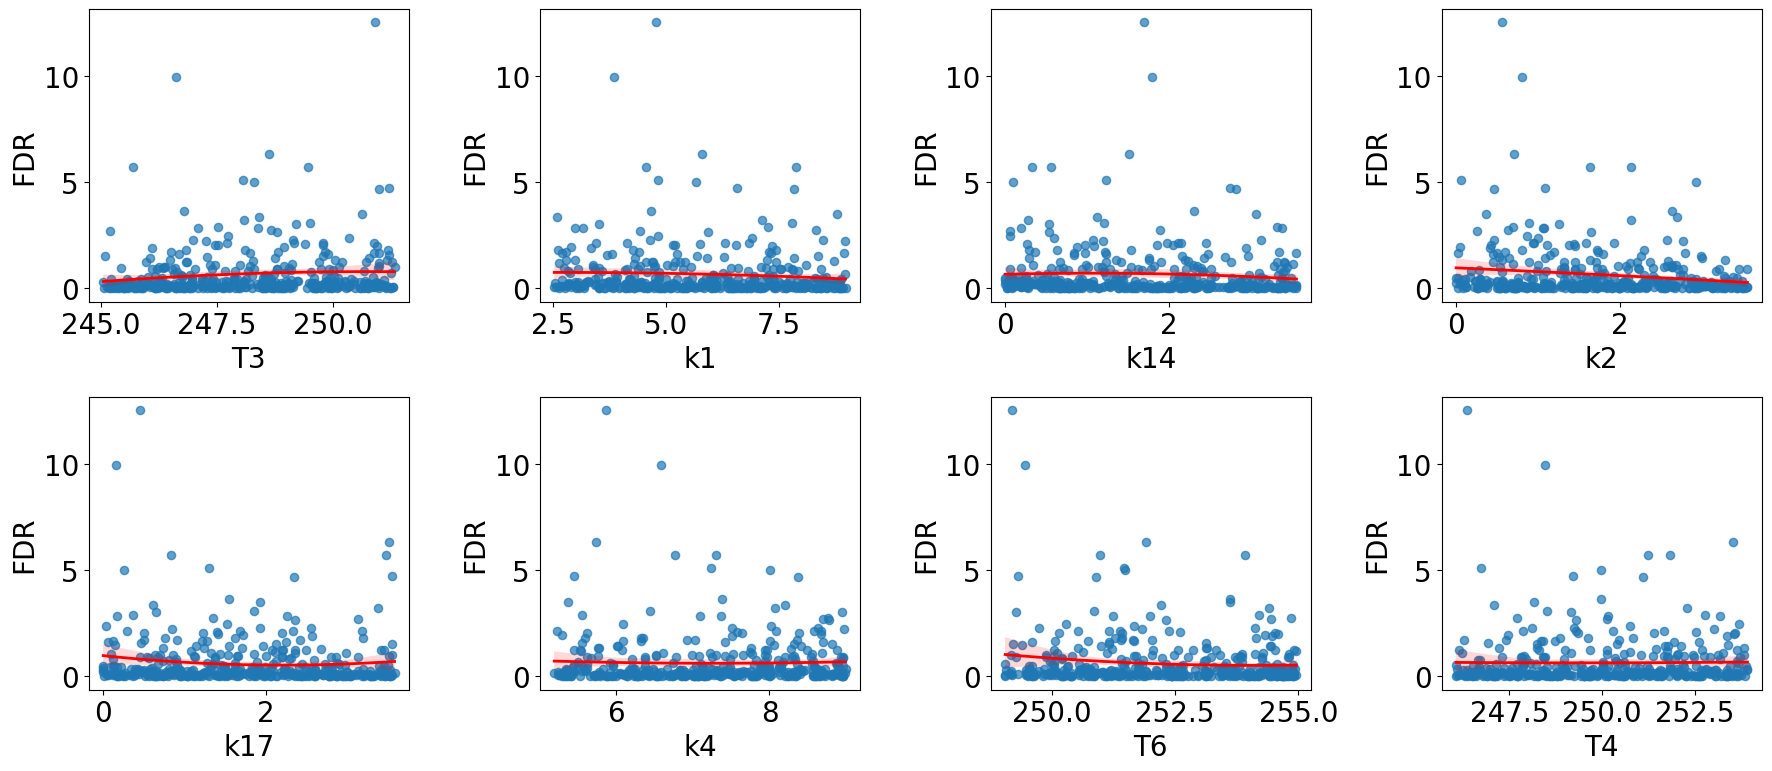


Number of settings used for regression: 400

Best LASSO alpha: 0.0880488

LASSO coefficients using FDR:
Parameter  LASSO_coefficient  Absolute_coefficient
       k2          -0.095155              0.095155
       T6          -0.050175              0.050175
       T3           0.029983              0.029983
       k6          -0.019391              0.019391
      k18           0.016122              0.016122
      k10          -0.002225              0.002225
       k9          -0.000000              0.000000
      k19           0.000000              0.000000
      k17          -0.000000              0.000000
      k16           0.000000              0.000000
      k15          -0.000000              0.000000
      k14          -0.000000              0.000000
      k13           0.000000              0.000000
      k12           0.000000              0.000000
      k11           0.000000              0.000000
       k7           0.000000              0.000000
       k8           0.000000

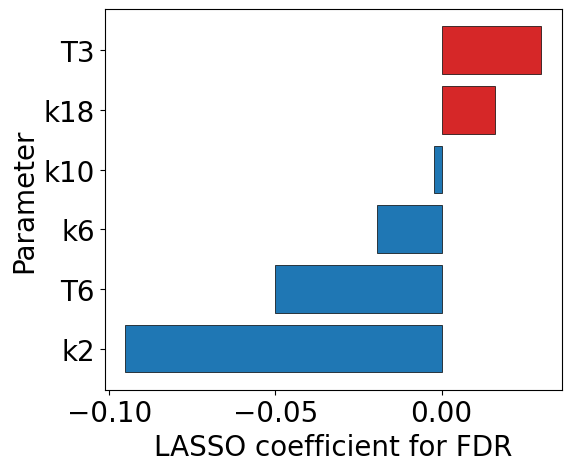


Ridge regression cross-validation using FDR:
R²:  -0.013 ± 0.018
MAE [FDR]: 0.71188 ± 0.0695727


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold

run = 'round5'

#### Font Sizing
#SMALL_SIZE =12
#MEDIUM_SIZE = 15
#BIGGER_SIZE = 18
SMALL_SIZE =16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24


plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
#### 

# =======================================================
# 0. Read data
# =======================================================

sorted_400 = pd.read_csv(f'{run}_y_values_sorted.csv')
parameters_400 = pd.read_csv(f'{run}_pairing_results_data1.csv')

print("FDR file columns:")
print(sorted_400.columns.tolist())

print("\nParameter file columns:")
print(parameters_400.columns.tolist())


# =======================================================
# 1. Merge FDR and parameter data
# =======================================================

fdr_df = sorted_400[['pairing_num', 'FDR_distance']].copy()

# Ensure pairing_num has the same type in both DataFrames
fdr_df['pairing_num'] = pd.to_numeric(
    fdr_df['pairing_num'], errors='coerce'
)

parameters_400['pairing_num'] = pd.to_numeric(
    parameters_400['pairing_num'], errors='coerce'
)

df = pd.merge(
    fdr_df,
    parameters_400,
    on='pairing_num',
    how='inner'
)

print(f"\nNumber of matched settings: {len(df)}")


# =======================================================
# # 2. Extract T3-T10 and k1-k20
# # 1. Define the explicit 28 selected parameters
# =======================================================

# Temperatures: T3 through T10
temperature_columns = [f'T{i}' for i in range(3, 11)]

# Interaction/weight parameters: k1 through k20
k_columns = [f'k{i}' for i in range(1, 21)]

# Total: 8 temperature parameters + 20 k parameters = 28
parameter_names = temperature_columns + k_columns

if len(parameter_names) != 28:
    raise ValueError(
        f'Expected 28 selected parameters, found {len(parameter_names)}.'
    )

print("\nSelected 28 parameters:")
print(parameter_names)

# Confirm required columns exist in pairing-results file.
required_parameter_columns = ['pairing_num'] + parameter_names

missing_columns = [
    column for column in required_parameter_columns
    if column not in parameters_400.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing from "
        f"'{run}_pairing_results_data1.csv':\n{missing_columns}\n\n"
        f"Available columns:\n{parameters_400.columns.tolist()}"
    )


# =======================================================
# 2. Select only pairing_num, T3-T10, k1-k20, then merge
# =======================================================

# Keep only pairing_num and FDR from the ranking/FDR file.
fdr_df = sorted_400[['pairing_num', 'FDR_distance']].copy()

# Keep only pairing_num and the 28 requested parameters.
# This intentionally excludes rand1, T1, and T2.
parameter_df = parameters_400[
    ['pairing_num'] + parameter_names
].copy()

# Make pairing_num types consistent before merging.
fdr_df['pairing_num'] = pd.to_numeric(
    fdr_df['pairing_num'],
    errors='coerce'
)

parameter_df['pairing_num'] = pd.to_numeric(
    parameter_df['pairing_num'],
    errors='coerce'
)

# Remove malformed pairing IDs, if they exist.
fdr_df = fdr_df.dropna(subset=['pairing_num']).copy()
parameter_df = parameter_df.dropna(subset=['pairing_num']).copy()

# Optional: change to integer only if your pairing numbers are integers.
fdr_df['pairing_num'] = fdr_df['pairing_num'].astype(int)
parameter_df['pairing_num'] = parameter_df['pairing_num'].astype(int)

# Merge FDR with exactly the selected 28 parameters.
df = pd.merge(
    fdr_df,
    parameter_df,
    on='pairing_num',
    how='inner',
    validate='one_to_one'
)

print(f"\nNumber of matched settings: {len(df)}")

# Verify final column order.
selected_columns = ['pairing_num', 'FDR_distance'] + parameter_names
df = df[selected_columns].copy()

print("\nFinal selected columns:")
print(df.columns.tolist())

print("\nFirst five selected rows:")
print(df.head())

# =======================================================
# 3. Clean numeric data
# =======================================================

# Convert FDR and all selected parameters to numeric values.
df['FDR_distance'] = pd.to_numeric(
    df['FDR_distance'],
    errors='coerce'
)

for param in parameter_names:
    df[param] = pd.to_numeric(df[param], errors='coerce')

# FDR should generally be non-negative.
# Keep zero values because we are NOT taking log(FDR).
df = df[df['FDR_distance'].notna()].copy()
df = df[df['FDR_distance'] >= 0].copy()

print("\nFDR summary:")
print(df['FDR_distance'].describe())

print("\nFirst five merged rows:")
print(df[['pairing_num', 'FDR_distance'] + parameter_names].head())


# =======================================================
# 4. Spearman and Pearson correlations with FDR
# =======================================================

correlation_results = []

for param in parameter_names:

    valid = df[[param, 'FDR_distance']].dropna()

    # Avoid correlation errors for parameters that never change.
    if valid[param].nunique() <= 1:
        spearman_r = np.nan
        spearman_p = np.nan
        pearson_r = np.nan
        pearson_p = np.nan

        print(f"Warning: {param} is constant; correlation is undefined.")

    else:
        spearman_r, spearman_p = spearmanr(
            valid[param],
            valid['FDR_distance']
        )

        pearson_r, pearson_p = pearsonr(
            valid[param],
            valid['FDR_distance']
        )

    correlation_results.append({
        'Parameter': param,
        'Spearman_r': spearman_r,
        'Spearman_p': spearman_p,
        'Pearson_r': pearson_r,
        'Pearson_p': pearson_p,
        'Abs_Spearman_r': abs(spearman_r) if not np.isnan(spearman_r) else np.nan,
        'N_samples': len(valid)
    })

correlation_table = pd.DataFrame(correlation_results)

# Strongest individual monotonic relationship first
correlation_table = correlation_table.sort_values(
    by='Abs_Spearman_r',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

print("\nCorrelation with FDR:")
print(correlation_table.to_string(index=False))

#save1: correlation_table.to_csv(f'{run}_parameter_FDR_correlations.csv',index=False)

# =======================================================
# 5. Spearman correlation bar plot
# =======================================================

plot_df = correlation_table.dropna(
    subset=['Spearman_r']
).sort_values('Spearman_r')

plt.figure(figsize=(10, 9))

colors = [
    'tab:red' if value > 0 else 'tab:blue'
    for value in plot_df['Spearman_r']
]

plt.barh(
    plot_df['Parameter'],
    plot_df['Spearman_r'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Spearman correlation with FDR')
plt.ylabel('Parameter')
#plt.title(f'{run}: Individual parameter relationships with raw FDR')

plt.tight_layout()
#save2:
plt.savefig(f'{run}_spearman_parameter_FDR.pdf', bbox_inches='tight')
plt.show()


# =======================================================
# 6. Scatter plots for the eight strongest parameters
# =======================================================

top_n = 8

top_parameters = correlation_table.dropna(
    subset=['Spearman_r']
).head(top_n)['Parameter'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, param in zip(axes, top_parameters):

    plot_data = df[[param, 'FDR_distance']].dropna()

    sns.regplot(
        data=plot_data,
        x=param,
        y='FDR_distance',
        ax=ax,
        order=2,  # quadratic curve
        scatter_kws={
            's': 35,
            'alpha': 0.70,
            'color': 'tab:blue'
        },
        line_kws={
            'color': 'red',
            'linewidth': 2
        }
    )

    result = correlation_table.loc[
        correlation_table['Parameter'] == param
    ].iloc[0]
    #ax.set_title(f"{param}: Spearman r = {result['Spearman_r']:.2f}")
    ax.set_xlabel(param)
    ax.set_ylabel('FDR')

# Hide unused axes, if any
for ax in axes[len(top_parameters):]:
    ax.set_visible(False)

plt.tight_layout()
#save3:
plt.savefig(f'{run}_top8_Spearman_FDR_relationships.pdf',bbox_inches='tight')
plt.show()


# =======================================================
# 7. LASSO regression using FDR
# =======================================================

X = df[parameter_names].copy()
y = df['FDR_distance'].copy()

# Remove rows with missing parameter/FDR values.
valid_rows = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print(f"\nNumber of settings used for regression: {len(X)}")

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# StandardScaler scales the INPUT parameters only.
# It does not transform the FDR response variable.
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(
        alphas=np.logspace(-6, 2, 200),
        cv=cv,
        max_iter=100000,
        random_state=42
    )
)

lasso_model.fit(X, y)

lasso = lasso_model.named_steps['lassocv']

lasso_results = pd.DataFrame({
    'Parameter': parameter_names,
    'LASSO_coefficient': lasso.coef_,
    'Absolute_coefficient': np.abs(lasso.coef_)
}).sort_values(
    'Absolute_coefficient',
    ascending=False
).reset_index(drop=True)

print(f"\nBest LASSO alpha: {lasso.alpha_:.6g}")
print("\nLASSO coefficients using FDR:")
print(lasso_results.to_string(index=False))

#save4: lasso_results.to_csv(f'{run}_LASSO_rawFDR_parameter_importance.csv',index=False)


# =======================================================
# 8. Plot LASSO-selected parameters
# =======================================================

selected = lasso_results[
    lasso_results['Absolute_coefficient'] > 1e-12
].sort_values('LASSO_coefficient')

if selected.empty:
    print("\nLASSO selected no parameters.")

else:
    plt.figure(figsize=(6, max(5, 0.4 * len(selected))))

    colors = [
        'tab:red' if coefficient > 0 else 'tab:blue'
        for coefficient in selected['LASSO_coefficient']
    ]

    plt.barh(
        selected['Parameter'],
        selected['LASSO_coefficient'],
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    #plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('LASSO coefficient for FDR')
    plt.ylabel('Parameter')
    #plt.title(f'{run}: LASSO-selected parameters for FDR')
    plt.tight_layout()
    #save5: 
    plt.savefig(f'{run}_LASSO_FDR_coefficients.pdf',bbox_inches='tight')
    plt.show()


# =======================================================
# 9. Ridge regression cross-validation using FDR
# =======================================================

ridge_model = make_pipeline(
    StandardScaler(),
    RidgeCV(
        alphas=np.logspace(-6, 6, 200),
        cv=cv
    )
)

r2_scores = cross_val_score(
    ridge_model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

mae_scores = -cross_val_score(
    ridge_model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

print("\nRidge regression cross-validation using FDR:")
print(f'R²:  {r2_scores.mean():.3f} ± {r2_scores.std():.3f}')
print(f'MAE [FDR]: {mae_scores.mean():.6g} ± {mae_scores.std():.6g}')